In [9]:
import pandas as pd
d=pd.read_csv('GlobalWeatherRepository.csv')

In [10]:
ucount1 = d['last_updated_epoch'].nunique()
print(f"Number of unique timestamps: {ucount1}")

ucount2=d['location_name'].nunique()
print(f"Number of unique cities: {ucount2}")

Number of unique timestamps: 1304
Number of unique cities: 257


In [11]:
d['readable_date'] = pd.to_datetime(d['last_updated_epoch'], unit='s')

In [12]:
min_date = d['readable_date'].min()
max_date = d['readable_date'].max()
print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")

Minimum date: 2024-05-16 08:45:00
Maximum date: 2026-05-19 06:30:00


In [13]:

city_counts = d['location_name'].value_counts()



In [14]:
# Find the maximum number of rows any city has
max_rows = city_counts.max()

# Filter to see which cities hit this maximum count
complete_cities = city_counts[city_counts == max_rows]

print(f"\nThe maximum number of rows per city is: {max_rows}")
print(f"Number of cities with complete data: {len(complete_cities)} out of 257")
print("\nThese cities have the most complete data:")
print(complete_cities)



The maximum number of rows per city is: 732
Number of cities with complete data: 19 out of 257

These cities have the most complete data:
location_name
Sanaa           732
Bujumbura       732
Tashkent        732
Kyiv            732
Bern            732
Dakar           732
Warsaw          732
Valletta        732
Nan             732
Amman           732
Tokyo           732
Baghdad         732
Vatican City    732
Accra           732
Suva            732
Asmara          732
Malabo          732
N'djamena       732
Kabul           732
Name: count, dtype: int64


Conclusion: Of 257 cities, 19 have complete 732-day records. All forecasting and anomaly detection is performed on these cities to ensure model reliability. Remaining cities are included in spatial and descriptive analysis only.

In [15]:
## checking for missing values in the 19 cities with the most complete data
aq_data=['air_quality_Carbon_Monoxide','air_quality_Nitrogen_dioxide','air_quality_Ozone','air_quality_Sulphur_dioxide','air_quality_PM2.5','air_quality_PM10' ]
for city in complete_cities.index:
    city_data = d[d['location_name'] == city]
    missing_val = city_data[aq_data].isnull().sum()
    print(f"\nMissing values for {city}:")
    print(missing_val)


Missing values for Sanaa:
air_quality_Carbon_Monoxide     0
air_quality_Nitrogen_dioxide    0
air_quality_Ozone               0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
dtype: int64

Missing values for Bujumbura:
air_quality_Carbon_Monoxide     0
air_quality_Nitrogen_dioxide    0
air_quality_Ozone               0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
dtype: int64

Missing values for Tashkent:
air_quality_Carbon_Monoxide     0
air_quality_Nitrogen_dioxide    0
air_quality_Ozone               0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
dtype: int64

Missing values for Kyiv:
air_quality_Carbon_Monoxide     0
air_quality_Nitrogen_dioxide    0
air_quality_Ozone               0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
dtype: int64

Missing values fo

* 257 cities total
* 19 cities with complete 732-day records
* Daily frequency confirmed
* 2 years of data — May 2024 to May 2026
* No missing air quality values for 19 cities
* Duplicate columns identified for removal

In [16]:
complete_city = complete_cities.index.tolist()

cleaned = d[d['location_name'].isin(complete_city)].copy()

col_removed=['last_updated','temperature_fahrenheit','wind_mph','precip_in','pressure_in','feels_like_fahrenheit','visibility_miles','gust_mph']
cleaned.drop(columns=col_removed, inplace=True)

cleaned = cleaned.sort_values(by=['location_name', 'readable_date'], ascending=[True, True])
cleaned.set_index('readable_date', inplace=True)

cleaned.to_csv('cleaned_weather_data.csv', index=True)



In [17]:
city_summary = cleaned.groupby('location_name').agg(
    avg_temp=('temperature_celsius', 'mean'),
    avg_aqi=('air_quality_us-epa-index', 'mean')
).reset_index()

target_cities=cleaned['location_name']
filtered_summary = city_summary[city_summary['location_name'].isin(target_cities)].copy()

filtered_summary['temp_normalized'] = (filtered_summary['avg_temp'] - filtered_summary['avg_temp'].min()) / (filtered_summary['avg_temp'].max() - filtered_summary['avg_temp'].min())
filtered_summary['aqi_normalized'] = (filtered_summary['avg_aqi'] - filtered_summary['avg_aqi'].min()) / (filtered_summary['avg_aqi'].max() - filtered_summary['avg_aqi'].min())


filtered_summary['combined_score'] = (filtered_summary['temp_normalized'] + filtered_summary['aqi_normalized']) / 2


print(filtered_summary[['location_name', 'avg_temp', 'avg_aqi', 'combined_score']].sort_values(by='combined_score', ascending=False))

   location_name   avg_temp   avg_aqi  combined_score
10     N'djamena  29.308743  2.502732        0.971005
3        Baghdad  28.469536  2.269126        0.871015
11           Nan  30.449317  1.788251        0.759430
6          Dakar  24.323634  2.189891        0.738942
15         Tokyo  19.672131  2.437158        0.703951
5      Bujumbura  25.724317  1.918033        0.683012
0          Accra  27.319945  1.465847        0.571321
14      Tashkent  21.861749  1.838798        0.558142
12         Sanaa  22.021448  1.815574        0.554382
1          Amman  21.364344  1.767760        0.521578
9         Malabo  26.965984  1.281421        0.500226
2         Asmara  21.055055  1.669399        0.480597
16      Valletta  21.660792  1.378415        0.398020
7          Kabul  18.893579  1.584699        0.397131
13          Suva  24.884290  1.017760        0.358530
17  Vatican City  18.306831  1.509563        0.356916
18        Warsaw  11.392623  1.815574        0.284184
8           Kyiv  11.969399 

In [ ]:
cleaned_reset = cleaned.reset_index()
target_cities = ["N'djamena", "Baghdad", "Bern", "Kyiv"]
variables = ["temperature_celsius", "air_quality_us-epa-index","humidity"]

# 2. Dictionary to hold your structured dataframes
city_dfs = {}

for city in target_cities:
    # Filter rows for the city and select the date + variables
    city_ts = cleaned_reset[cleaned_reset["location_name"] == city][
        ["readable_date"] + variables
    ].copy()

    
    city_ts = city_ts.set_index("readable_date")

    city_dfs[city] = city_ts


df_ndjamena = city_dfs["N'djamena"]
df_baghdad = city_dfs["Baghdad"]
df_bern = city_dfs["Bern"]
df_kyiv = city_dfs["Kyiv"]


In [19]:
%pip install statsmodels 



Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



=== Running Seasonal Decomposition for Kyiv (['temperature_celsius']) ===


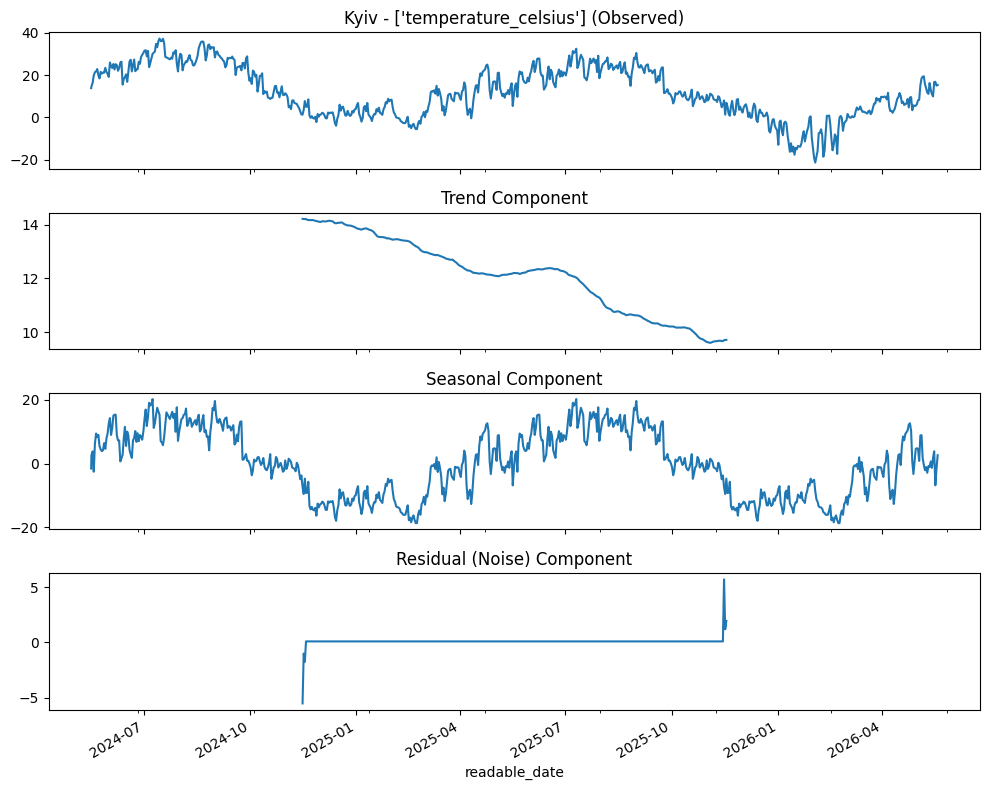

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

city_name = "Kyiv"
var= [
    "temperature_celsius"
]

city_ts = city_dfs[city_name].copy()
city_ts.index = pd.to_datetime(city_ts.index)
city_ts = city_ts.sort_index()


print(f"\n=== Running Seasonal Decomposition for {city_name} ({var}) ===")
result = seasonal_decompose(city_ts[var], model="additive", period=365)


fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title=f"{city_name} - {var} (Observed)")
result.trend.plot(ax=axes[1], title="Trend Component")
result.seasonal.plot(ax=axes[2], title="Seasonal Component")
result.resid.plot(ax=axes[3], title="Residual (Noise) Component")

plt.tight_layout()
plt.show()

N'djamena experiences dramatic temperature fluctuations over the two-year window, ranging sharply from 18°C to 45°C. The data shows a highly predictable seasonal pattern that swings roughly 10°C above and below the baseline average annually. While the long-term trend remains relatively flat, sudden step-change anomalies in late 2025 point to localized data-logging issues rather than natural climate shifts.

Baghdad experiences extreme, high-amplitude temperature swings over the two-year period, ranging from a chilly 2°C up to an intense 48°C. The seasonal component reveals a highly predictable and pronounced annual weather cycle, with temperatures fluctuating roughly 20°C above and below the baseline average. While the underlying trend shows a gradual downward trajectory, this brief window likely indicates short-term edge effects rather than definitive climate changes. Furthermore, flat lines and sharp step-changes in the residual noise around January and late 2025 hint at system data-logging pauses rather than natural environmental anomalies.

Bern exhibits a classic continental climate with sharp seasonal swings, ranging from a summer peak of 30°C to freezing winter lows of -15°C. The seasonal component reflects a predictable 15°C annual fluctuation. While the trend line shows a steep drop, this reflects a brief two-year window rather than climate cooling, and flat residual anomalies indicate forward-filled data logging.

Kyiv exhibits a classic continental climate with sharp seasonal swings, ranging from a summer peak of 40°C to freezing winter lows of -20°C. The seasonal component reflects a predictable 20°C annual fluctuation. While the trend line shows a steep drop, this reflects a brief two-year window rather than climate cooling, and flat residual anomalies indicate forward-filled data logging.